<a href="https://colab.research.google.com/github/ClarkeNeedles/VisualizingWildfires/blob/main/Final_Project_Code_Clarke_N.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Part 1

link: https://colab.research.google.com/drive/1aoFpAL34vNhVURydTXsHbNMB2KH7_NxW?usp=sharing

In [ ]:
!pip install geopandas
import pandas as pd
import seaborn as sns
import numpy as np
import folium
from folium import plugins
import geopandas as gpd
import matplotlib.pyplot as plt

     |████████████████████████████████| 994 kB 24.5 MB/s 
     |████████████████████████████████| 15.4 MB 35 kB/s 
     |████████████████████████████████| 6.6 MB 28.9 MB/s 


In [ ]:
df = ('https://raw.githubusercontent.com/justinabella/gecsummer2021/main/new-york-state-wildfire-2008-2019.csv')
newyork_df = pd.read_csv(df)
newyork_df

,Fire Number,Incident Name,Fire Start Date,Initial Report Date,Fire Out Date,Region,Zone,County,Municipality,Cause,NFFL Fuel Model,Complex Type,Acreage,Latitude,Longitude,Ownership,State Land Unit Name,Non-Personnel Expenses,Fatalities,Injuries,Homes Lost,Homes Threatened,Other Structures Lost,Other Structures Threatened,Reporting Ranger,Fire Report Method,Railroad Name,Location 1,New York Zip Codes,Counties,NYS Municipal Boundaries
0,NYS-2019-0103,Tracy Creek Fire 2,2019-11-10T00:00:00.000,2019-11-10T00:00:00.000,2019-11-12T00:00:00.000,8,8A,STEUBEN,RATHBONE,Campfire,8 - Timber - Light Hardwood Litter,5.0,0.1,42.15465,-77.33731,State Forest/RF Area,Tracy Creek State Forest,0.0,0,0,0,0,0,0,"Staples,Anne M",Other,NaN,"{'latitude': '42.15465', 'longitude': '-77.337...",1766.0,2178.0,25.0
1,NYS-2019-0102,"LIne Road East RX, Part 2",2019-10-26T00:00:00.000,2019-10-26T00:00:00.000,2019-10-26T00:00:00.000,1,1A,SUFFOLK,RIVERHEAD,Prescribed Fire,1 - Grass - Light,5.0,0.9,40.90302,-72.81499,State Forest/RF Area,PECONIC HEADWATERS,0.0,0,0,0,0,0,0,"Gallagher,Bryan",Ranger Patrol,NaN,"{'latitude': '40.90302', 'longitude': '-72.814...",1607.0,2179.0,1017.0
2,NYS-2019-0101,Line Road East RX,2019-10-19T00:00:00.000,2019-10-19T00:00:00.000,2019-10-19T00:00:00.000,1,1A,SUFFOLK,RIVERHEAD,Prescribed Fire,3 - Grass - Heavy,4.0,9.0,40.90336,-72.81437,State Forest/RF Area,PECONIC HEADWATERS,0.0,0,0,0,0,0,0,"Gallagher,Bryan",Ranger Patrol,NaN,"{'latitude': '40.90336', 'longitude': '-72.814...",1607.0,2179.0,1017.0
3,NYS-2019-0100,Randalls Rd Fire,2019-10-15T00:00:00.000,2019-10-15T00:00:00.000,2019-10-17T00:00:00.000,5,5F,WASHINGTON,ARGYLE,Debris Burning,8 - Timber - Light Hardwood Litter,5.0,1.5,43.23349,-73.43347,Forest Preserve,NaN,0.0,0,0,0,0,0,0,"Hess,Joseph C",911 Dispatch,NaN,"{'latitude': '43.23349', 'longitude': '-73.433...",787.0,2184.0,731.0
4,NYS-2019-0099,Yellowjacket Fire,2019-09-27T00:00:00.000,2019-09-27T00:00:00.000,2019-09-29T00:00:00.000,4,4A,GREENE,CAIRO,Campfire,9 - Timber - Medium Hardwood Litter,5.0,0.3,42.26957,-74.09964,Forest Preserve,Windham Blackhead WA,0.0,0,0,0,0,0,0,"Fox,Katherine M",911 Dispatch,NaN,"{'latitude': '42.26957', 'longitude': '-74.099...",262.0,2087.0,761.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1741,NYS-2008-0005,Prestons Pond,2008-03-22T00:00:00.000,2008-03-22T00:00:00.000,2008-03-22T00:00:00.000,1,1A,SUFFOLK,RIVERHEAD,Prescribed Fire,1 - Grass - Light,5.0,5.8,40.90210,-72.82048,Wildlife Management Area,Peconic River HWNRMA,0.0,0,0,0,0,0,0,"Byrnes,Timothy",Supervisor,NaN,"{'latitude': '40.9021', 'longitude': '-72.82048'}",1607.0,2179.0,1017.0
1742,NYS-2008-0004,Quadt Fire,2008-03-22T00:00:00.000,2008-03-22T00:00:00.000,2008-03-22T00:00:00.000,4,4B,SCHOHARIE,SCHOHARIE,Miscellaneous,1 - Grass - Light,5.0,0.2,42.65000,-74.32000,Private Property,NaN,0.0,0,0,0,0,0,0,"Henry,William",911 Dispatch,NaN,"{'latitude': '42.65', 'longitude': '-74.32'}",1404.0,629.0,146.0
1743,NYS-2008-0003,Otis Pike @ Linus Dog Pond,2008-03-18T00:00:00.000,2008-03-18T00:00:00.000,2008-03-18T00:00:00.000,1,1A,SUFFOLK,RIVERHEAD,Prescribed Fire,1 - Grass - Light,5.0,2.3,40.88800,-72.81800,Wildlife Management Area,Peconic River HWNRMA,0.0,0,0,0,0,0,0,"Byrnes,Timothy",Supervisor,NaN,"{'latitude': '40.888', 'longitude': '-72.818'}",1607.0,2179.0,1017.0
1744,NYS-2008-0002,Otis Pike @ Dog Pond Line Rd,2008-03-18T00:00:00.000,2008-03-18T00:00:00.000,2008-03-18T00:00:00.000,1,1A,SUFFOLK,RIVERHEAD,Prescribed Fire,1 - Grass - Light,5.0,10.9,40.90200,-72.80200,Wildlife Management Area,Peconic River HWNRMA,0.0,0,0,0,0,0,0,"Byrnes,Timothy",Supervisor,NaN,"{'latitude': '40.902', 'longitude': '-72.802'}",1607.0,2179.0,1017.0


Question 1

In [ ]:
newyork_df = newyork_df.drop(columns=['Complex Type', 'State Land Unit Name', 'Reporting Ranger', 'Fire Report Method', 'Railroad Name', 'Location 1', 'New York Zip Codes', 'Counties', 'NYS Municipal Boundaries'])
newyork_df


,Fire Number,Incident Name,Fire Start Date,Initial Report Date,Fire Out Date,Region,Zone,County,Municipality,Cause,NFFL Fuel Model,Acreage,Latitude,Longitude,Ownership,Non-Personnel Expenses,Fatalities,Injuries,Homes Lost,Homes Threatened,Other Structures Lost,Other Structures Threatened
0,NYS-2019-0103,Tracy Creek Fire 2,2019-11-10T00:00:00.000,2019-11-10T00:00:00.000,2019-11-12T00:00:00.000,8,8A,STEUBEN,RATHBONE,Campfire,8 - Timber - Light Hardwood Litter,0.1,42.15465,-77.33731,State Forest/RF Area,0.0,0,0,0,0,0,0
1,NYS-2019-0102,"LIne Road East RX, Part 2",2019-10-26T00:00:00.000,2019-10-26T00:00:00.000,2019-10-26T00:00:00.000,1,1A,SUFFOLK,RIVERHEAD,Prescribed Fire,1 - Grass - Light,0.9,40.90302,-72.81499,State Forest/RF Area,0.0,0,0,0,0,0,0
2,NYS-2019-0101,Line Road East RX,2019-10-19T00:00:00.000,2019-10-19T00:00:00.000,2019-10-19T00:00:00.000,1,1A,SUFFOLK,RIVERHEAD,Prescribed Fire,3 - Grass - Heavy,9.0,40.90336,-72.81437,State Forest/RF Area,0.0,0,0,0,0,0,0
3,NYS-2019-0100,Randalls Rd Fire,2019-10-15T00:00:00.000,2019-10-15T00:00:00.000,2019-10-17T00:00:00.000,5,5F,WASHINGTON,ARGYLE,Debris Burning,8 - Timber - Light Hardwood Litter,1.5,43.23349,-73.43347,Forest Preserve,0.0,0,0,0,0,0,0
4,NYS-2019-0099,Yellowjacket Fire,2019-09-27T00:00:00.000,2019-09-27T00:00:00.000,2019-09-29T00:00:00.000,4,4A,GREENE,CAIRO,Campfire,9 - Timber - Medium Hardwood Litter,0.3,42.26957,-74.09964,Forest Preserve,0.0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1741,NYS-2008-0005,Prestons Pond,2008-03-22T00:00:00.000,2008-03-22T00:00:00.000,2008-03-22T00:00:00.000,1,1A,SUFFOLK,RIVERHEAD,Prescribed Fire,1 - Grass - Light,5.8,40.90210,-72.82048,Wildlife Management Area,0.0,0,0,0,0,0,0
1742,NYS-2008-0004,Quadt Fire,2008-03-22T00:00:00.000,2008-03-22T00:00:00.000,2008-03-22T00:00:00.000,4,4B,SCHOHARIE,SCHOHARIE,Miscellaneous,1 - Grass - Light,0.2,42.65000,-74.32000,Private Property,0.0,0,0,0,0,0,0
1743,NYS-2008-0003,Otis Pike @ Linus Dog Pond,2008-03-18T00:00:00.000,2008-03-18T00:00:00.000,2008-03-18T00:00:00.000,1,1A,SUFFOLK,RIVERHEAD,Prescribed Fire,1 - Grass - Light,2.3,40.88800,-72.81800,Wildlife Management Area,0.0,0,0,0,0,0,0
1744,NYS-2008-0002,Otis Pike @ Dog Pond Line Rd,2008-03-18T00:00:00.000,2008-03-18T00:00:00.000,2008-03-18T00:00:00.000,1,1A,SUFFOLK,RIVERHEAD,Prescribed Fire,1 - Grass - Light,10.9,40.90200,-72.80200,Wildlife Management Area,0.0,0,0,0,0,0,0


Question 2

In [ ]:
maxValueIndex = newyork_df['Non-Personnel Expenses'].idxmax()
newyork_df.loc[maxValueIndex, ['Incident Name', 'Fire Start Date','Latitude', 'Longitude', 'County']]

#The fires name was Flat Rock Fire and it occured July 12, 2018
#I also printed out the latitude, longitude and county for question 3.1

Incident Name               Flat Rock Fire
Fire Start Date    2018-07-12T00:00:00.000
Latitude                           44.8745
Longitude                         -73.6375
County                             CLINTON
Name: 149, dtype: object

Question 3 + Question 4


In [ ]:
for index, row in newyork_df.iterrows():
  newyork_df['year'][index] = row['Fire Start Date'][:4]
  if newyork_df['year'][index] != '2019':
    newyork_df = newyork_df.drop([index], axis=0)

newyork_df

/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  


,Fire Number,Incident Name,Fire Start Date,Initial Report Date,Fire Out Date,Region,Zone,County,Municipality,Cause,NFFL Fuel Model,Acreage,Latitude,Longitude,Ownership,Non-Personnel Expenses,Fatalities,Injuries,Homes Lost,Homes Threatened,Other Structures Lost,Other Structures Threatened,year
0,NYS-2019-0103,Tracy Creek Fire 2,2019-11-10T00:00:00.000,2019-11-10T00:00:00.000,2019-11-12T00:00:00.000,8,8A,STEUBEN,RATHBONE,Campfire,8 - Timber - Light Hardwood Litter,0.1,42.15465,-77.33731,State Forest/RF Area,0.0,0,0,0,0,0,0,2019
1,NYS-2019-0102,"LIne Road East RX, Part 2",2019-10-26T00:00:00.000,2019-10-26T00:00:00.000,2019-10-26T00:00:00.000,1,1A,SUFFOLK,RIVERHEAD,Prescribed Fire,1 - Grass - Light,0.9,40.90302,-72.81499,State Forest/RF Area,0.0,0,0,0,0,0,0,2019
2,NYS-2019-0101,Line Road East RX,2019-10-19T00:00:00.000,2019-10-19T00:00:00.000,2019-10-19T00:00:00.000,1,1A,SUFFOLK,RIVERHEAD,Prescribed Fire,3 - Grass - Heavy,9.0,40.90336,-72.81437,State Forest/RF Area,0.0,0,0,0,0,0,0,2019
3,NYS-2019-0100,Randalls Rd Fire,2019-10-15T00:00:00.000,2019-10-15T00:00:00.000,2019-10-17T00:00:00.000,5,5F,WASHINGTON,ARGYLE,Debris Burning,8 - Timber - Light Hardwood Litter,1.5,43.23349,-73.43347,Forest Preserve,0.0,0,0,0,0,0,0,2019
4,NYS-2019-0099,Yellowjacket Fire,2019-09-27T00:00:00.000,2019-09-27T00:00:00.000,2019-09-29T00:00:00.000,4,4A,GREENE,CAIRO,Campfire,9 - Timber - Medium Hardwood Litter,0.3,42.26957,-74.09964,Forest Preserve,0.0,0,0,0,0,0,0,2019
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
98,NYS-2019-0005,Willard St Fire,2019-03-27T00:00:00.000,2019-03-27T00:00:00.000,2019-03-27T00:00:00.000,9,9A,CHAUTAUQUA,POLAND,Debris Burning,1 - Grass - Light,2.0,42.10012,-79.17110,Private Property,0.0,0,0,0,0,0,0,2019
99,NYS-2019-0004,Rhinebeck Brush Fire,2019-03-26T00:00:00.000,2019-03-26T00:00:00.000,2019-03-26T00:00:00.000,3,3B,DUTCHESS,RHINEBECK,Debris Burning,1 - Grass - Light,0.3,41.89700,-73.87160,Private Property,0.0,0,0,0,0,0,0,2019
100,NYS-2019-0003,Thomas Corners Fire,2019-03-26T00:00:00.000,2019-03-26T00:00:00.000,2019-03-26T00:00:00.000,9,9A,CATTARAUGUS,ASHFORD,Debris Burning,1 - Grass - Light,3.2,42.48002,-78.64870,Private Property,0.0,0,0,0,0,0,0,2019
101,NYS-2019-0002,Flushing Meadows Fire 2,2019-03-13T00:00:00.000,2019-03-13T00:00:00.000,2019-03-13T00:00:00.000,2,2A,QUEENS,QUEENS,Incendiary,1 - Grass - Light,0.1,40.72285,-73.82807,Other Not Classified,0.0,0,0,0,0,0,0,2019


# Part 2

Question 1

([<matplotlib.patches.Wedge at 0x7fbbb3c6f7d0>,
 [Text(0.6970218465090311, 0.8509762308602637, 'Campfire'),
  Text(-0.9203998896804738, 0.6023819743951275, 'Prescribed Fire'),
  Text(-0.7954055088908094, -0.7598223979497793, 'Debris Burning'),
  Text(0.05030892623203347, -1.098848948646437, 'Smoking'),
  Text(0.6438464395219173, -0.8918866308645681, 'Incendiary'),
  Text(0.9203999214049495, -0.6023819259222201, 'Children'),
  Text(1.0012277631554896, -0.45556883814266197, 'Lightning'),
  Text(1.0492286792956376, -0.33033192177495113, 'Miscellaneous'),
  Text(1.081631316902314, -0.20018415096147477, 'Fireworks'),
  Text(1.0953982041179482, -0.100512558494818, 'Power line'),
  Text(1.0994883723687554, -0.03354577508278747, 'Structure')],
 [Text(0.38019373445947147, 0.46416885319650747, '28.16%'),
  Text(-0.5020363034620765, 0.32857198603370585, '25.24%'),
  Text(-0.4338575503040778, -0.4144485806998796, '17.48%'),
  Text(0.027441232490200074, -0.5993721538071474, '9.71%'),
  Text(0.35118

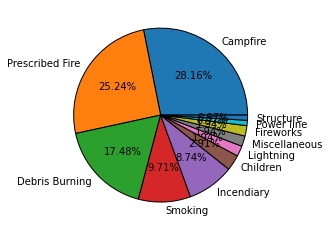

In [ ]:
cause = newyork_df['Cause'].unique()
count = newyork_df['Cause'].value_counts()
plt.pie(count, labels= cause, wedgeprops= {'edgecolor': 'black'}, autopct= '%.2f%%')

#Campfires were the leading cause for all of the 104 wildfires in 2019. (28.16% of all fires)

Question 2

/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  if __name__ == '__main__':
/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  import sys
/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  del sys.path[0]
/usr/local/lib/python3.7/dist-packages/ipykernel_launc

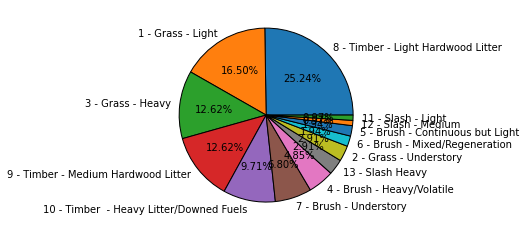

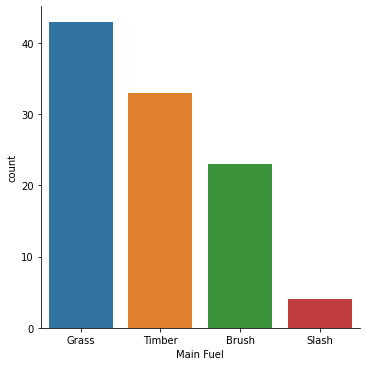

In [ ]:
cause = newyork_df['NFFL Fuel Model'].unique()
count = newyork_df['NFFL Fuel Model'].value_counts()
plt.pie(count, labels= cause, wedgeprops= {'edgecolor': 'black'}, autopct= '%.2f%%')

for index, row in newyork_df.iterrows():
  if 'Grass' in newyork_df['NFFL Fuel Model'][index]:
    newyork_df['Main Fuel'][index]  = 'Grass'
  elif 'Timber' in newyork_df['NFFL Fuel Model'][index]:
    newyork_df['Main Fuel'][index] = 'Timber'
  elif 'Slash' in newyork_df['NFFL Fuel Model'][index]:
    newyork_df['Main Fuel'][index] = 'Slash'
  elif 'Brush' in newyork_df['NFFL Fuel Model'][index]:
    newyork_df['Main Fuel'][index] = 'Brush'

sns.catplot(data = newyork_df, kind = 'count', x = 'Main Fuel', order=['Grass', 'Timber', 'Brush', 'Slash'])

#Grass, Timber, Brush and Slash are the main types of fuel, but mostly grass and timber acount for the majority of fires.

Question 3

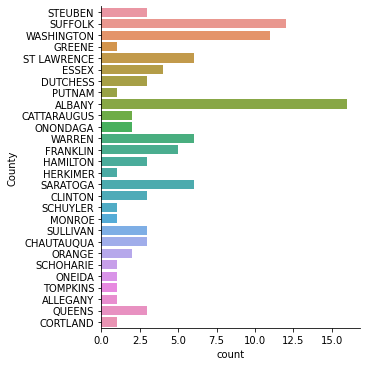

In [ ]:
sns.catplot(data=newyork_df, kind = 'count', y='County')

# Part 3

Question 1

In [ ]:
newyork_map = folium.Map(location=[43.2994, -74.2179], zoom_start=7)
folium.Marker(location=[44.8745, -73.6375], popup='County').add_to(newyork_map)

newyork_map

Question 2

In [ ]:
for index, row in newyork_df.iterrows():
  folium.CircleMarker(location=[row['Latitude'], row['Longitude']],radius=1,popup=row['County'], fill_color="#3db7e4", ).add_to(newyork_map)

newyork_map

Question 3

In [ ]:
newyork_counties = newyork_df[['Latitude', 'Longitude']].values

folium.plugins.HeatMap(newyork_counties, radius=16).add_to(newyork_map)
folium.LayerControl().add_to(newyork_map)
newyork_map